# Comparing Emerging Market vs Developed Market Volatility

*Quant Lab · The Analytical Investor · Year 1, Month 11*

**Read the article:** [Comparing Emerging Market vs Developed Market Volatility](https://analytical-investor.blog/?p=1032)

Developed, emerging and frontier return series compared on volatility, skew, tails and autocorrelation, including how stale prices make a risky market look calm.

> Run locally with `pip install -e ".[notebooks]"` from the repo root, then open this notebook in Jupyter. All data is simulated with fixed seeds, so every number matches the article.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.3})

## Step 1
Simulate the three markets, profile them, and undo the frontier smoothing.

In [2]:
import numpy as np
from scipy import stats

rng = np.random.default_rng(33)
n = 252 * 20                                   # twenty years, daily

# ------------------------------------------------------------------
# 1. Developed market: moderately fat-tailed, mild clustering
# ------------------------------------------------------------------
def garch_series(n, mu, omega, alpha, beta, dof, jump_p=0.0,
                 jump_mu=0.0, jump_sig=0.0, seed_rng=rng):
    """GARCH(1,1) with Student-t shocks and optional jumps."""
    r, h = np.empty(n), omega / (1 - alpha - beta)
    for t in range(n):
        z = seed_rng.standard_t(dof) / np.sqrt(dof / (dof - 2))
        r[t] = mu + np.sqrt(h) * z
        if jump_p and seed_rng.random() < jump_p:
            r[t] += seed_rng.normal(jump_mu, jump_sig)
        h = omega + alpha * (r[t] - mu)**2 + beta * h
    return r

dm = garch_series(n, mu=0.07/252,
                  omega=2e-6, alpha=0.08, beta=0.90, dof=7)

# Emerging market: higher vol, fatter tails, crash jumps (devaluations)
em = garch_series(n, mu=0.10/252,
                  omega=5e-6, alpha=0.12, beta=0.86, dof=4,
                  jump_p=0.002, jump_mu=-0.06, jump_sig=0.03)

# Frontier market: the SAME EM returns, seen through stale, smoothed prices
# (Geltner model: observed_t = (1 - a) * true_t + a * observed_{t-1})
a_smooth = 0.35
fm = np.empty(n)
prev = 0.0
for t in range(n):                             # prices adjust only partially
    prev = (1 - a_smooth) * em[t] + a_smooth * prev
    fm[t] = prev

# ------------------------------------------------------------------
# 2. The comparison battery
# ------------------------------------------------------------------
def profile(r, label):
    ann_v = r.std() * np.sqrt(252)
    skew, kurt = stats.skew(r), stats.kurtosis(r)   # excess kurtosis
    var99 = -np.quantile(r, 0.01)
    es99 = -r[r <= np.quantile(r, 0.01)].mean()
    worst = -r.min()
    ac1 = np.corrcoef(r[:-1], r[1:])[0, 1]
    cum = np.cumprod(1 + r)
    mdd = (cum / np.maximum.accumulate(cum) - 1).min()
    print(f"{label:<9} vol {ann_v:6.1%}  skew {skew:5.2f}  "
          f"kurt {kurt:5.1f}  VaR99 {var99:5.2%}  ES99 {es99:5.2%}  "
          f"worst {worst:5.2%}  AC1 {ac1:5.2f}  MaxDD {mdd:6.1%}")

for r, lab in [(dm, "DM"), (em, "EM"), (fm, "Frontier")]:
    profile(r, lab)

# ------------------------------------------------------------------
# 3. Unsmooth the frontier series (Geltner-style) and re-profile
# ------------------------------------------------------------------
a = np.corrcoef(fm[:-1], fm[1:])[0, 1]
fm_unsm = (fm[1:] - a * fm[:-1]) / (1 - a)
profile(fm_unsm, "Frontier*")                  # * = unsmoothed

DM        vol  13.9%  skew  0.00  kurt   1.6  VaR99 2.34%  ES99 2.79%  worst 4.38%  AC1  0.02  MaxDD -37.8%
EM        vol  22.8%  skew -0.81  kurt  21.9  VaR99 4.05%  ES99 6.50%  worst 20.90%  AC1  0.01  MaxDD -52.3%
Frontier  vol  15.8%  skew -0.60  kurt  17.6  VaR99 2.68%  ES99 4.53%  worst 12.80%  AC1  0.34  MaxDD -51.0%
Frontier* vol  22.5%  skew -0.80  kurt  21.8  VaR99 3.99%  ES99 6.41%  worst 20.58%  AC1  0.02  MaxDD -52.2%


### Volatility comes in waves
Rolling 63-day volatility. Note how the smoothed frontier series looks calmer than the identical EM returns underneath it.

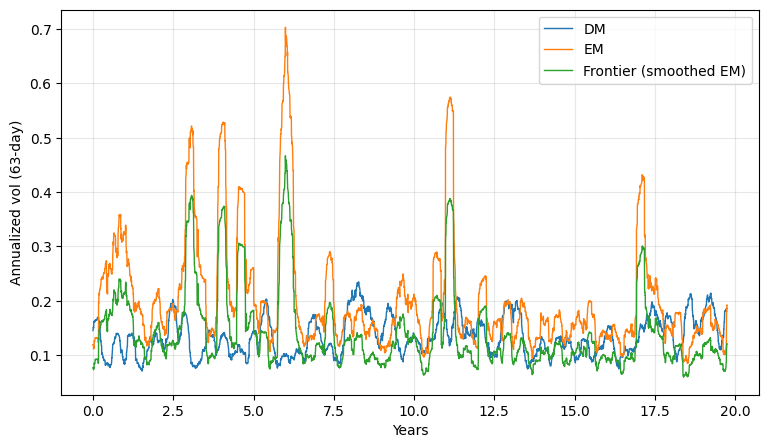

In [3]:
def rolling_vol(x, w=63):
    return np.sqrt(np.convolve(x**2, np.ones(w) / w, mode="valid") * 252)
t = np.arange(len(rolling_vol(dm))) / 252
for x, lab in [(dm, "DM"), (em, "EM"), (fm, "Frontier (smoothed EM)")]:
    plt.plot(t, rolling_vol(x), label=lab, lw=1)
plt.xlabel("Years"); plt.ylabel("Annualized vol (63-day)"); plt.legend(); plt.show()

## The same thing with the toolkit
The model above lives in the `analytical_investor` package, tested and reusable.

In [4]:
from analytical_investor import distributions

for lab, x in [("Frontier", fm), ("Frontier unsmoothed", distributions.geltner_unsmooth(fm))]:
    p = distributions.profile(x)
    print(f"{lab:<20} vol {p['vol']:.1%}  ac1 {p['ac1']:.2f}  es99 {p['es99']:.2%}")

Frontier             vol 15.8%  ac1 0.34  es99 4.53%
Frontier unsmoothed  vol 22.5%  ac1 0.02  es99 6.41%


---
The article's **Limitations** section explains what this model leaves out. [Read it here](https://analytical-investor.blog/?p=1032).